# Feature Significance Testing
Tests: Point-Biserial Correlation, Mann-Whitney U, Chi-Square, Correlation Matrix, VIF

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pointbiserialr, mannwhitneyu, chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# Load filtered data and re-engineer features (same as preprocessing)
df = pd.read_parquet('../data/loans_filtered.parquet')
df = df.copy()

FEATURES = [
    'dti', 'earliest_cr_line', 'purpose', 'annual_inc', 'pub_rec',
    'loan_amnt', 'int_rate', 'installment', 'grade', 'emp_length',
    'home_ownership', 'verification_status', 'open_acc', 'revol_bal',
    'revol_util', 'total_acc', 'mort_acc', 'delinq_2yrs', 'inq_last_6mths',
    'target'
]
df = df[FEATURES].copy()

# Feature engineering
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')
df['credit_history_years'] = (pd.Timestamp('2018-12-31') - df['earliest_cr_line']).dt.days / 365
df = df.drop(columns=['earliest_cr_line'])
df['has_derogatory'] = (df['pub_rec'] > 0).astype(int)
df = df.drop(columns=['pub_rec'])
income_cap = df['annual_inc'].quantile(0.99)
df['annual_inc'] = df['annual_inc'].clip(0, income_cap)
emp_map = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
           '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
           '8 years': 8, '9 years': 9, '10+ years': 10}
df['emp_length'] = df['emp_length'].map(emp_map)
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade'] = df['grade'].map(grade_map)

# Drop NaN targets
df = df[df['target'].notna()]

# Impute for significance testing
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'target']
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Ready for significance testing. Shape:', df.shape)

Ready for significance testing. Shape: (1348059, 20)


## Test 1: Point-Biserial Correlation
Measures linear correlation between each numeric feature and the binary target.
Range: -1 to +1. Values near 0 = weak signal.

Point-Biserial Correlation with target:
             feature  correlation  p_value significant
               grade       0.2613      0.0         YES
            int_rate       0.2586      0.0         YES
                 dti       0.0842      0.0         YES
            mort_acc      -0.0725      0.0         YES
      inq_last_6mths       0.0660      0.0         YES
           loan_amnt       0.0653      0.0         YES
          annual_inc      -0.0630      0.0         YES
          revol_util       0.0600      0.0         YES
         installment       0.0514      0.0         YES
credit_history_years      -0.0438      0.0         YES
      has_derogatory       0.0315      0.0         YES
            open_acc       0.0279      0.0         YES
           revol_bal      -0.0196      0.0         YES
         delinq_2yrs       0.0193      0.0         YES
          emp_length      -0.0136      0.0         YES
           total_acc      -0.0114      0.0         YES


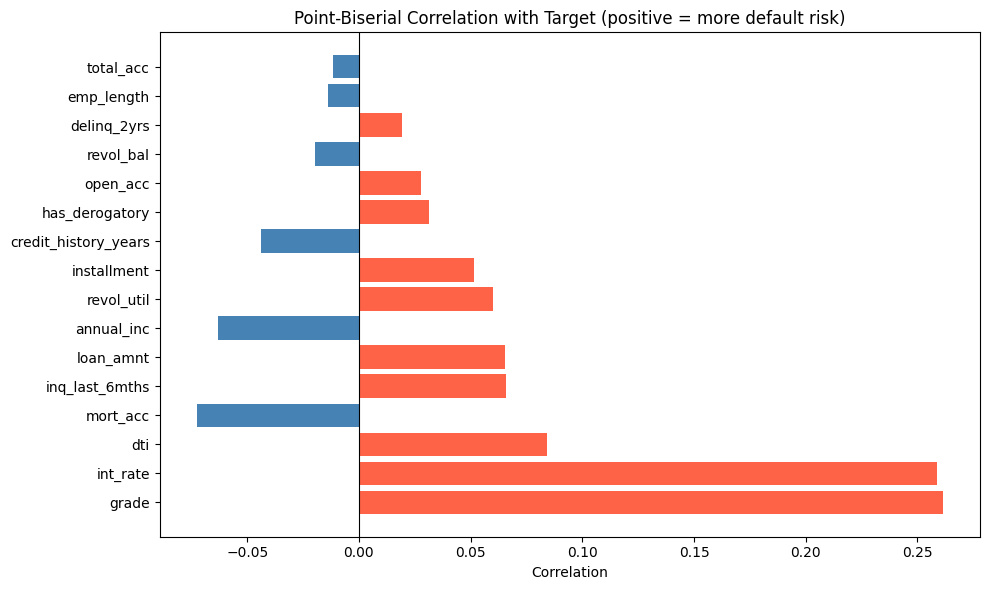

In [2]:
results_pb = []
y = df['target']

for col in num_cols:
    corr, pval = pointbiserialr(df[col].fillna(df[col].median()), y)
    results_pb.append({
        'feature': col,
        'correlation': round(corr, 4),
        'p_value': round(pval, 6),
        'significant': 'YES' if pval < 0.05 else 'NO'
    })

pb_df = pd.DataFrame(results_pb).sort_values('correlation', key=abs, ascending=False)
print('Point-Biserial Correlation with target:')
print(pb_df.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
colors = ['tomato' if c > 0 else 'steelblue' for c in pb_df['correlation']]
plt.barh(pb_df['feature'], pb_df['correlation'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Point-Biserial Correlation with Target (positive = more default risk)')
plt.xlabel('Correlation')
plt.tight_layout()
plt.savefig('../data/feature_correlation.png', dpi=100)
plt.show()

## Test 2: Mann-Whitney U Test
Non-parametric test. Checks if the distribution of a feature is significantly
different between defaulters and paid borrowers. Does NOT assume normal distribution.
p < 0.05 means the difference is statistically significant.

In [3]:
results_mw = []
group0 = df[df['target'] == 0]
group1 = df[df['target'] == 1]

for col in num_cols:
    stat, pval = mannwhitneyu(
        group0[col].dropna(),
        group1[col].dropna(),
        alternative='two-sided'
    )
    median_paid    = round(group0[col].median(), 4)
    median_default = round(group1[col].median(), 4)
    results_mw.append({
        'feature': col,
        'median_paid': median_paid,
        'median_default': median_default,
        'p_value': round(pval, 6),
        'significant': 'YES' if pval < 0.05 else 'NO'
    })

mw_df = pd.DataFrame(results_mw).sort_values('p_value')
print('Mann-Whitney U Test Results:')
print(mw_df.to_string(index=False))

Mann-Whitney U Test Results:
             feature  median_paid  median_default  p_value significant
                 dti      17.1100         19.7450      0.0         YES
          annual_inc   65000.0000      60000.0000      0.0         YES
           loan_amnt   12000.0000      14300.0000      0.0         YES
            int_rate      12.2900         15.0500      0.0         YES
         installment     367.8000        402.5400      0.0         YES
               grade       2.0000          3.0000      0.0         YES
          emp_length       6.0000          6.0000      0.0         YES
            open_acc      11.0000         11.0000      0.0         YES
           revol_bal   11147.0000      11065.0000      0.0         YES
          revol_util      51.3000         55.5000      0.0         YES
           total_acc      23.0000         23.0000      0.0         YES
            mort_acc       1.0000          1.0000      0.0         YES
         delinq_2yrs       0.0000          0.000

## Test 3: Chi-Square Test (Categorical Features)
Tests if a categorical feature and the target are independent.
p < 0.05 = they are related (feature is useful).

In [4]:
results_chi = []

for col in cat_cols:
    contingency = pd.crosstab(df[col], df['target'])
    chi2, pval, dof, expected = chi2_contingency(contingency)
    results_chi.append({
        'feature': col,
        'chi2_stat': round(chi2, 2),
        'p_value': round(pval, 6),
        'degrees_of_freedom': dof,
        'significant': 'YES' if pval < 0.05 else 'NO'
    })

chi_df = pd.DataFrame(results_chi).sort_values('chi2_stat', ascending=False)
print('Chi-Square Test Results (Categorical Features):')
print(chi_df.to_string(index=False))

Chi-Square Test Results (Categorical Features):
            feature  chi2_stat  p_value  degrees_of_freedom significant
verification_status   11270.98      0.0                   2         YES
     home_ownership    6732.79      0.0                   5         YES
            purpose    4182.80      0.0                  13         YES


## Test 4: Correlation Matrix (Multicollinearity Check)
Find pairs of features that are highly correlated with each other.
Correlated features are redundant — keeping both doesn't add information.
Rule of thumb: |correlation| > 0.85 → consider dropping one.

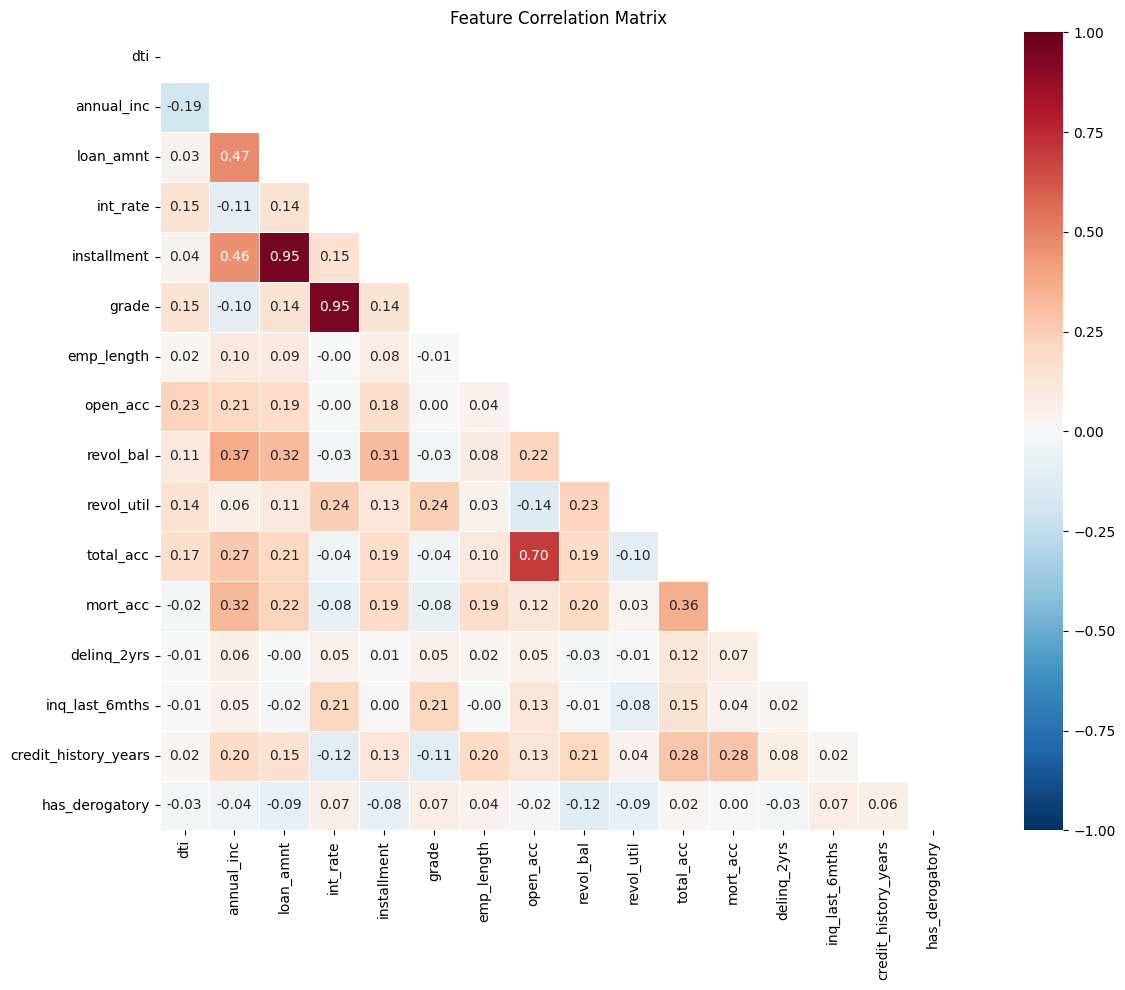

Highly correlated pairs (|r| > 0.7):
feature_1   feature_2  correlation
loan_amnt installment        0.953
 int_rate       grade        0.952
 open_acc   total_acc        0.701


In [5]:
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True
)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../data/correlation_matrix.png', dpi=100)
plt.show()

# Print high correlation pairs
print('Highly correlated pairs (|r| > 0.7):')
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append({
                'feature_1': corr_matrix.columns[i],
                'feature_2': corr_matrix.columns[j],
                'correlation': round(r, 3)
            })
if high_corr:
    print(pd.DataFrame(high_corr).sort_values('correlation', key=abs, ascending=False).to_string(index=False))
else:
    print('No pairs above 0.7 threshold')

## Test 5: VIF - Variance Inflation Factor
Measures how much a feature's variance is explained by other features.
VIF > 10 = severe multicollinearity (consider dropping).
VIF 5-10 = moderate (keep an eye on it).
VIF < 5 = acceptable.

In [6]:
vif_data = df[num_cols].dropna()

vif_results = []
for i, col in enumerate(num_cols):
    vif = variance_inflation_factor(vif_data.values, i)
    vif_results.append({'feature': col, 'VIF': round(vif, 2)})

vif_df = pd.DataFrame(vif_results).sort_values('VIF', ascending=False)
vif_df['verdict'] = vif_df['VIF'].apply(
    lambda v: 'DROP (severe)' if v > 10 else ('WATCH (moderate)' if v > 5 else 'OK')
)
print('VIF Results:')
print(vif_df.to_string(index=False))

VIF Results:
             feature   VIF          verdict
            int_rate 75.78    DROP (severe)
               grade 53.52    DROP (severe)
           loan_amnt 43.99    DROP (severe)
         installment 43.28    DROP (severe)
           total_acc 13.17    DROP (severe)
            open_acc 11.70    DROP (severe)
credit_history_years  8.04 WATCH (moderate)
          annual_inc  6.46 WATCH (moderate)
          revol_util  6.29 WATCH (moderate)
                 dti  4.35               OK
          emp_length  3.90               OK
            mort_acc  2.30               OK
           revol_bal  2.01               OK
      inq_last_6mths  1.65               OK
      has_derogatory  1.26               OK
         delinq_2yrs  1.17               OK


## Final Summary: Feature Ranking

In [7]:
# Combine point-biserial and Mann-Whitney results
summary = pb_df[['feature', 'correlation', 'significant']].copy()
summary.columns = ['feature', 'pb_correlation', 'pb_significant']
mw_sub = mw_df[['feature', 'p_value', 'significant']].copy()
mw_sub.columns = ['feature', 'mw_pvalue', 'mw_significant']
summary = summary.merge(mw_sub, on='feature')

# Rank by absolute correlation
summary['abs_corr'] = summary['pb_correlation'].abs()
summary = summary.sort_values('abs_corr', ascending=False).drop(columns='abs_corr')

print('=== FINAL FEATURE RANKING ===')
print(summary.to_string(index=False))
print('\nCategorical features (all significant if Chi-Square p < 0.05):')
print(chi_df[['feature', 'chi2_stat', 'significant']].to_string(index=False))

=== FINAL FEATURE RANKING ===
             feature  pb_correlation pb_significant  mw_pvalue mw_significant
               grade          0.2613            YES        0.0            YES
            int_rate          0.2586            YES        0.0            YES
                 dti          0.0842            YES        0.0            YES
            mort_acc         -0.0725            YES        0.0            YES
      inq_last_6mths          0.0660            YES        0.0            YES
           loan_amnt          0.0653            YES        0.0            YES
          annual_inc         -0.0630            YES        0.0            YES
          revol_util          0.0600            YES        0.0            YES
         installment          0.0514            YES        0.0            YES
credit_history_years         -0.0438            YES        0.0            YES
      has_derogatory          0.0315            YES        0.0            YES
            open_acc          0.02